In [38]:
import numpy as np 
import pandas as pd 

In [39]:
df = pd.read_csv('mobile_product_dataset_1000.csv')
df.head(5)

,Product_ID,Product_Name,Actual_Market_Price,Listed_Price,Rating,Reviews_Count,Seller_Score
0,P0001,iPhone 15 Pro,120000,118536,4.3,8369,99
1,P0002,iPhone 15 Pro,120000,119806,4.3,8480,85
2,P0003,Google Pixel 10,85000,84334,4.6,2841,85
3,P0004,Vivo X300 Pro,65000,64847,4.4,1554,90
4,P0005,Oppo Find X9 Pro,75000,72179,4.2,2664,87


In [40]:
df.isnull().sum()

Product_ID             0
Product_Name           0
Actual_Market_Price    0
Listed_Price           0
Rating                 0
Reviews_Count          0
Seller_Score           0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [49]:
# df.drop(columns=['Product_ID', 'Product_Name'], inplace=True)
X = df[[
    "Actual_Market_Price",
    "Listed_Price",
    "Rating",
    "Reviews_Count",
    "Seller_Score"
]]

In [50]:
from sklearn.preprocessing import StandardScaler

In [59]:
sc = StandardScaler()

In [60]:
x_scaled = sc.fit_transform(X)

In [68]:
x_scaled = pd.DataFrame(x_scaled, columns=X.columns)

In [69]:
x_scaled.describe()

,Actual_Market_Price,Listed_Price,Rating,Reviews_Count,Seller_Score
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,0.000000,-3.552714e-17,1.675104e-15,-4.440892e-17,1.758593e-16
std,1.000500,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.128434,-2.308441e+00,-1.722698e+00,-1.907049e+00,-3.768163e+00
25%,-0.777143,-6.092646e-01,-7.992471e-01,-7.603447e-01,2.633495e-02
50%,-0.250207,-2.317379e-01,1.242042e-01,4.310290e-02,2.528721e-01
75%,0.408463,5.101241e-01,1.047655e+00,8.429239e-01,4.794093e-01
max,1.945360,2.035653e+00,2.432832e+00,1.618437e+00,7.059465e-01


In [94]:
from sklearn.cluster import DBSCAN

In [95]:
for eps in [0.3,0.4,0.5,0.6,0.7,0.8]:
    model = DBSCAN(eps=eps, min_samples=5)
    clusters = model.fit_predict(x_scaled)

    print(
        f"eps={eps} | "
        f"Clusters={len(set(clusters))-(-1 in clusters)} | "
        f"Noise={(clusters==-1).sum()}"
    )

eps=0.3 | Clusters=31 | Noise=795
eps=0.4 | Clusters=35 | Noise=441
eps=0.5 | Clusters=13 | Noise=140
eps=0.6 | Clusters=6 | Noise=21
eps=0.7 | Clusters=4 | Noise=10
eps=0.8 | Clusters=4 | Noise=4


In [96]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(x_scaled)

In [97]:
df['Clusters'] = clusters

In [98]:
df['Clusters'].value_counts()

Clusters
 1     602
-1     140
 0      78
 2      72
 6      33
 4      23
 3      14
 11      7
 7       6
 5       6
 10      6
 9       5
 8       4
 12      4
Name: count, dtype: int64

In [107]:
df["Status"] = np.where(
    df["Clusters"] == -1,
    "Suspicious",
    "Genuine"
)

In [119]:
df.head(5)

,Product_ID,Product_Name,Actual_Market_Price,Listed_Price,Rating,Reviews_Count,Seller_Score,Clusters,Status
0,suspicious_products,suspicious_products,120000,118536,4.3,8369,99,-1,Suspicious
1,P0002,iPhone 15 Pro,120000,119806,4.3,8480,85,2,Genuine
2,P0003,Google Pixel 10,85000,84334,4.6,2841,85,0,Genuine
3,P0004,Vivo X300 Pro,65000,64847,4.4,1554,90,1,Genuine
4,P0005,Oppo Find X9 Pro,75000,72179,4.2,2664,87,1,Genuine


In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\pc\AppData\Local\Temp\ipykernel_19564\2685680165.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Status", palette={"Genuine": "seagreen", "Suspicious": "crimson"})


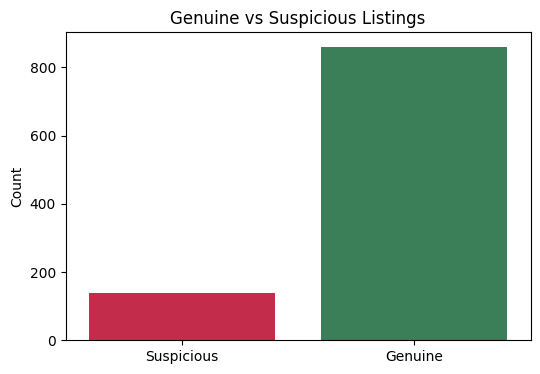

In [112]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Status", palette={"Genuine": "seagreen", "Suspicious": "crimson"})
plt.title("Genuine vs Suspicious Listings")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

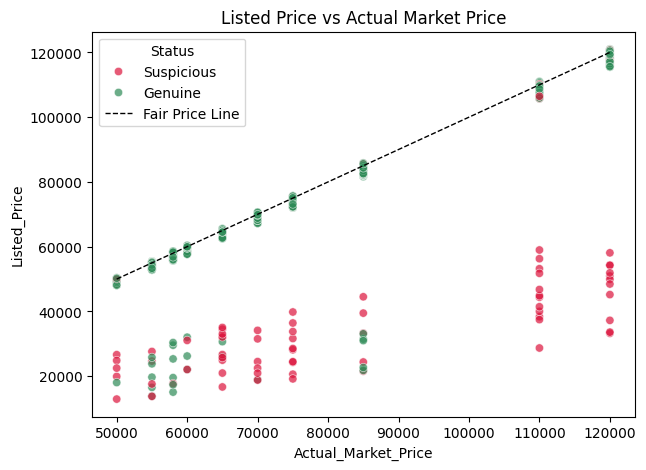

In [113]:
# ---------- 2. Listed Price vs Actual Market Price ----------
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df, x="Actual_Market_Price", y="Listed_Price",
    hue="Status",
    palette={"Genuine": "seagreen", "Suspicious": "crimson"},
    alpha=0.7
)
plt.plot(
    [df["Actual_Market_Price"].min(), df["Actual_Market_Price"].max()],
    [df["Actual_Market_Price"].min(), df["Actual_Market_Price"].max()],
    "k--", linewidth=1, label="Fair Price Line"
)
plt.title("Listed Price vs Actual Market Price")
plt.legend(title="Status")
plt.show()

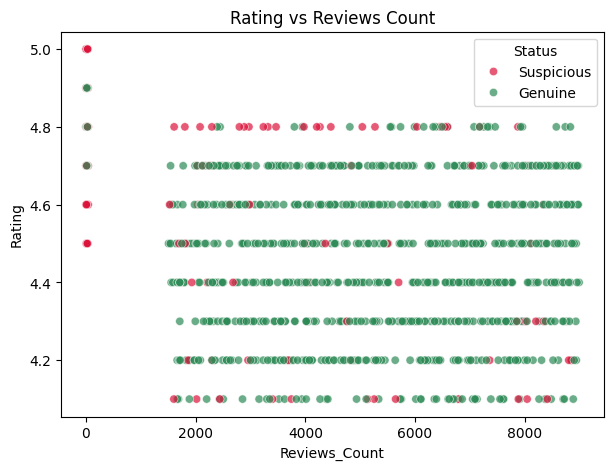

In [114]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df, x="Reviews_Count", y="Rating",
    hue="Status",
    palette={"Genuine": "seagreen", "Suspicious": "crimson"},
    alpha=0.7
)
plt.title("Rating vs Reviews Count")
plt.legend(title="Status")
plt.show()
 


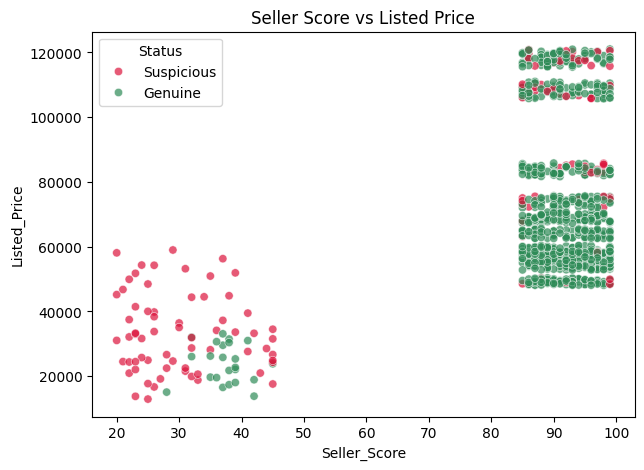

In [115]:
# ---------- 4. Seller_Score vs Listed_Price ----------
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df, x="Seller_Score", y="Listed_Price",
    hue="Status",
    palette={"Genuine": "seagreen", "Suspicious": "crimson"},
    alpha=0.7
)
plt.title("Seller Score vs Listed Price")
plt.legend(title="Status")
plt.show()
 


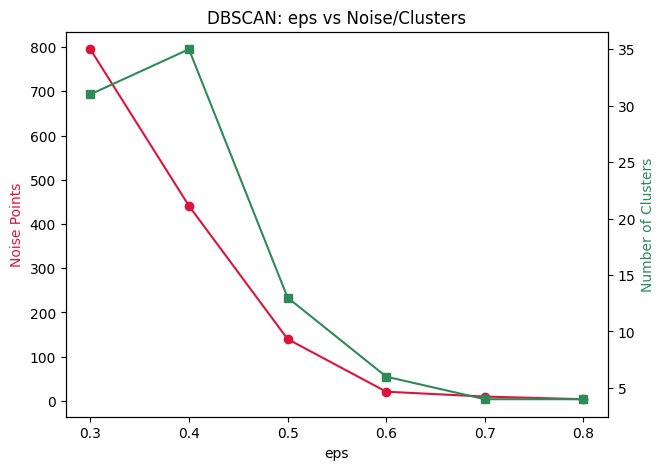

In [116]:
# ---------- 5. Eps vs Noise Points (DBSCAN tuning visual) ----------
from sklearn.cluster import DBSCAN
 
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
noise_counts = []
cluster_counts = []
 
for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    c = model.fit_predict(x_scaled)
    noise_counts.append((c == -1).sum())
    cluster_counts.append(len(set(c)) - (1 if -1 in c else 0))
 
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(eps_values, noise_counts, marker="o", color="crimson", label="Noise Points")
ax1.set_xlabel("eps")
ax1.set_ylabel("Noise Points", color="crimson")
 
ax2 = ax1.twinx()
ax2.plot(eps_values, cluster_counts, marker="s", color="seagreen", label="Clusters")
ax2.set_ylabel("Number of Clusters", color="seagreen")
 
plt.title("DBSCAN: eps vs Noise/Clusters")
plt.show()